Milestone 1

In [1]:
import pandas as pd

#import the CSV
df = pd.read_csv("C:\\Users\\hessk\\OneDrive\\Desktop\\DSC550\\Tornado Data.csv")

#display the first few rows to ensure it loaded properly
print(df.head())
print(df.info())

     yr  mo  dy      date  st  mag  inj  fat   slat   slon   elat   elon  \
0  1995   1   6  1/6/1995  LA    0    0    0  29.97 -92.17   0.00   0.00   
1  1995   1   6  1/6/1995  LA    1    0    0  31.52 -92.23  31.62 -92.05   
2  1995   1   6  1/6/1995  LA    1    8    0  30.23 -92.18  30.23 -92.10   
3  1995   1   6  1/6/1995  NC    0    3    1  34.70 -78.55   0.00   0.00   
4  1995   1   6  1/6/1995  NC    1    1    0  35.12 -78.10   0.00   0.00   

    len  wid  
0   0.2   20  
1  15.0   20  
2   5.0   30  
3   2.0  150  
4   1.0   73  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33364 entries, 0 to 33363
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   yr      33364 non-null  int64  
 1   mo      33364 non-null  int64  
 2   dy      33364 non-null  int64  
 3   date    33364 non-null  object 
 4   st      33364 non-null  object 
 5   mag     33364 non-null  int64  
 6   inj     33364 non-null  int64  
 7   fat   

In [2]:
import matplotlib.pyplot as plt

year = 'yr'

#count the number of tornadoes per year
tornadoes_per_year = df[year].value_counts().sort_index()

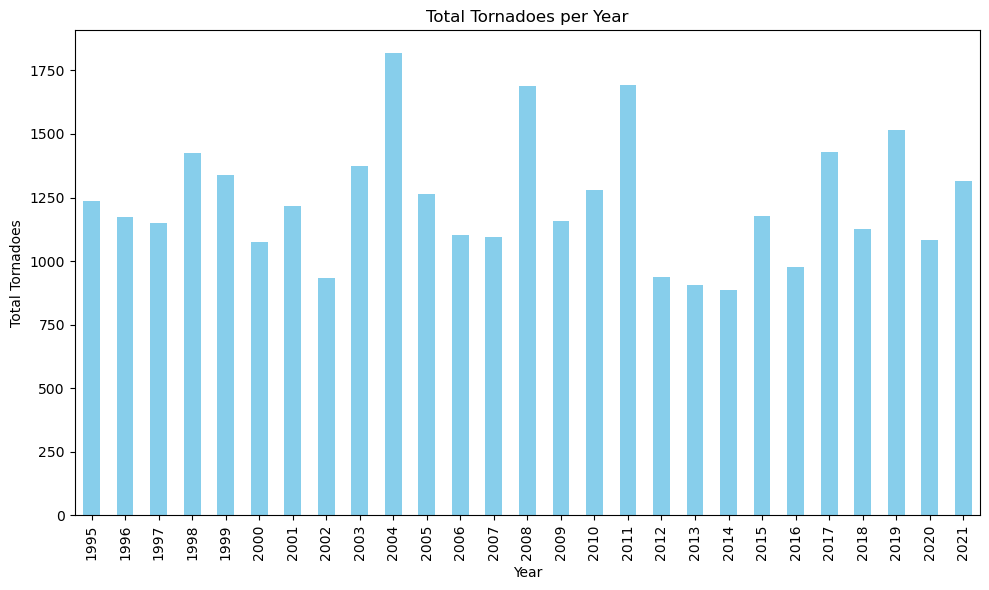

In [5]:
#plot the number of tornadoes per year
plt.figure(figsize=(10,6))
tornadoes_per_year.plot(kind='bar', color='skyblue')
plt.xlabel('Year')
plt.ylabel('Total Tornadoes')
plt.title('Total Tornadoes per Year')
plt.tight_layout()
plt.show()

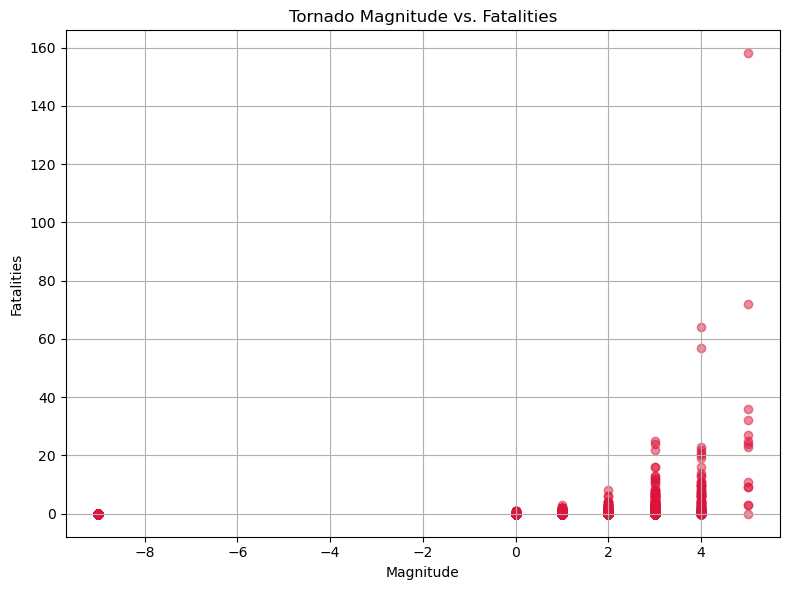

In [7]:
#plot of magnitude vs fatalities
plt.figure(figsize=(8,6))
plt.scatter(df['mag'], df['fat'], alpha=0.5, color='crimson')
plt.xlabel('Magnitude')
plt.ylabel('Fatalities')
plt.title('Tornado Magnitude vs. Fatalities')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
#give the variables easier to understand names
start_latitude = 'slat'
end_latitude = 'elat'
injuries = 'inj'
distance = 'len'
state = 'st'
width = 'wid'

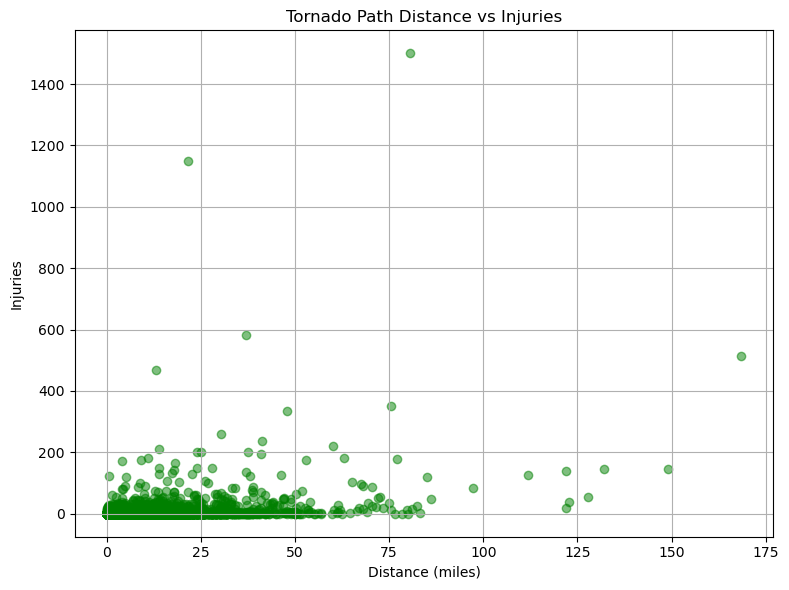

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(df[distance], df[injuries], alpha=0.5, color='green')
plt.xlabel('Distance (miles)')
plt.ylabel('Injuries')
plt.title('Tornado Path Distance vs Injuries')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
#find the total number of tornadoes per state
tornadoes_per_state = df[state].value_counts().sort_values(ascending=False)

print(tornadoes_per_state)

st
TX    3663
KS    2282
OK    1802
IL    1555
FL    1488
AL    1475
MS    1443
IA    1408
NE    1304
MO    1278
MN    1198
CO    1195
LA    1141
AR    1071
GA     925
NC     852
TN     837
ND     819
SD     729
KY     704
SC     697
IN     675
WI     631
OH     560
VA     510
PA     457
MI     364
WY     277
MD     248
CA     248
NM     245
NY     228
MT     193
AZ     115
ID     103
OR      77
WA      72
NJ      62
WV      62
CT      60
UT      58
ME      54
MA      49
NV      46
NH      23
PR      21
DE      19
HI      14
VT      14
RI       6
DC       3
AK       3
VI       1
Name: count, dtype: int64


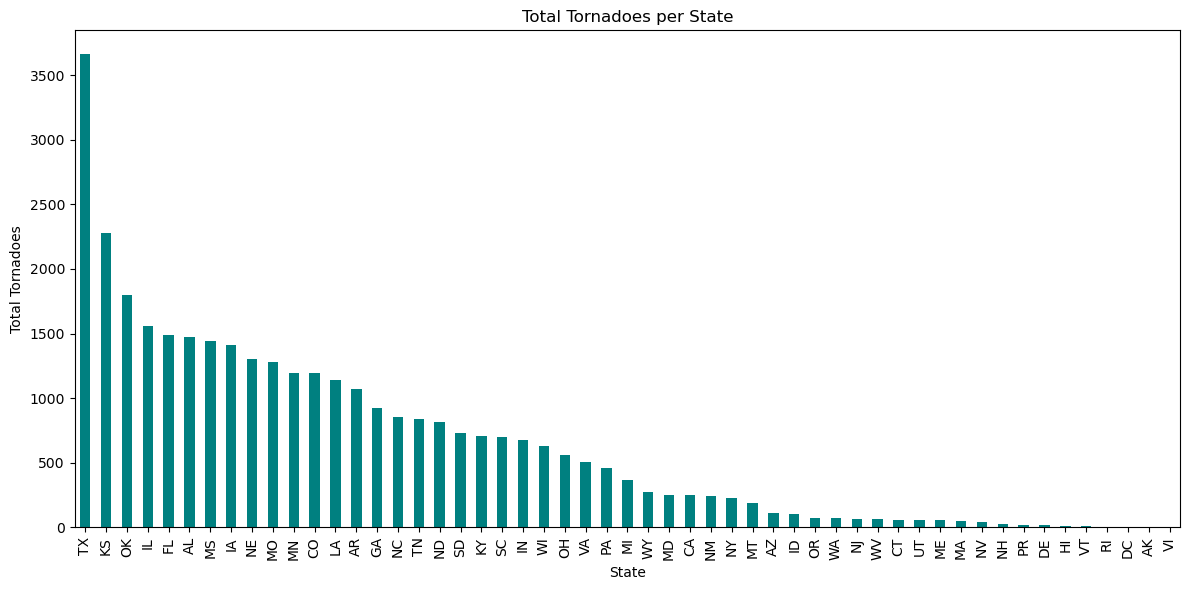

In [15]:
plt.figure(figsize=(12,6))
tornadoes_per_state.plot(kind='bar', color='teal')
plt.xlabel('State')
plt.ylabel('Total Tornadoes')
plt.title('Total Tornadoes per State')
plt.tight_layout()
plt.show()

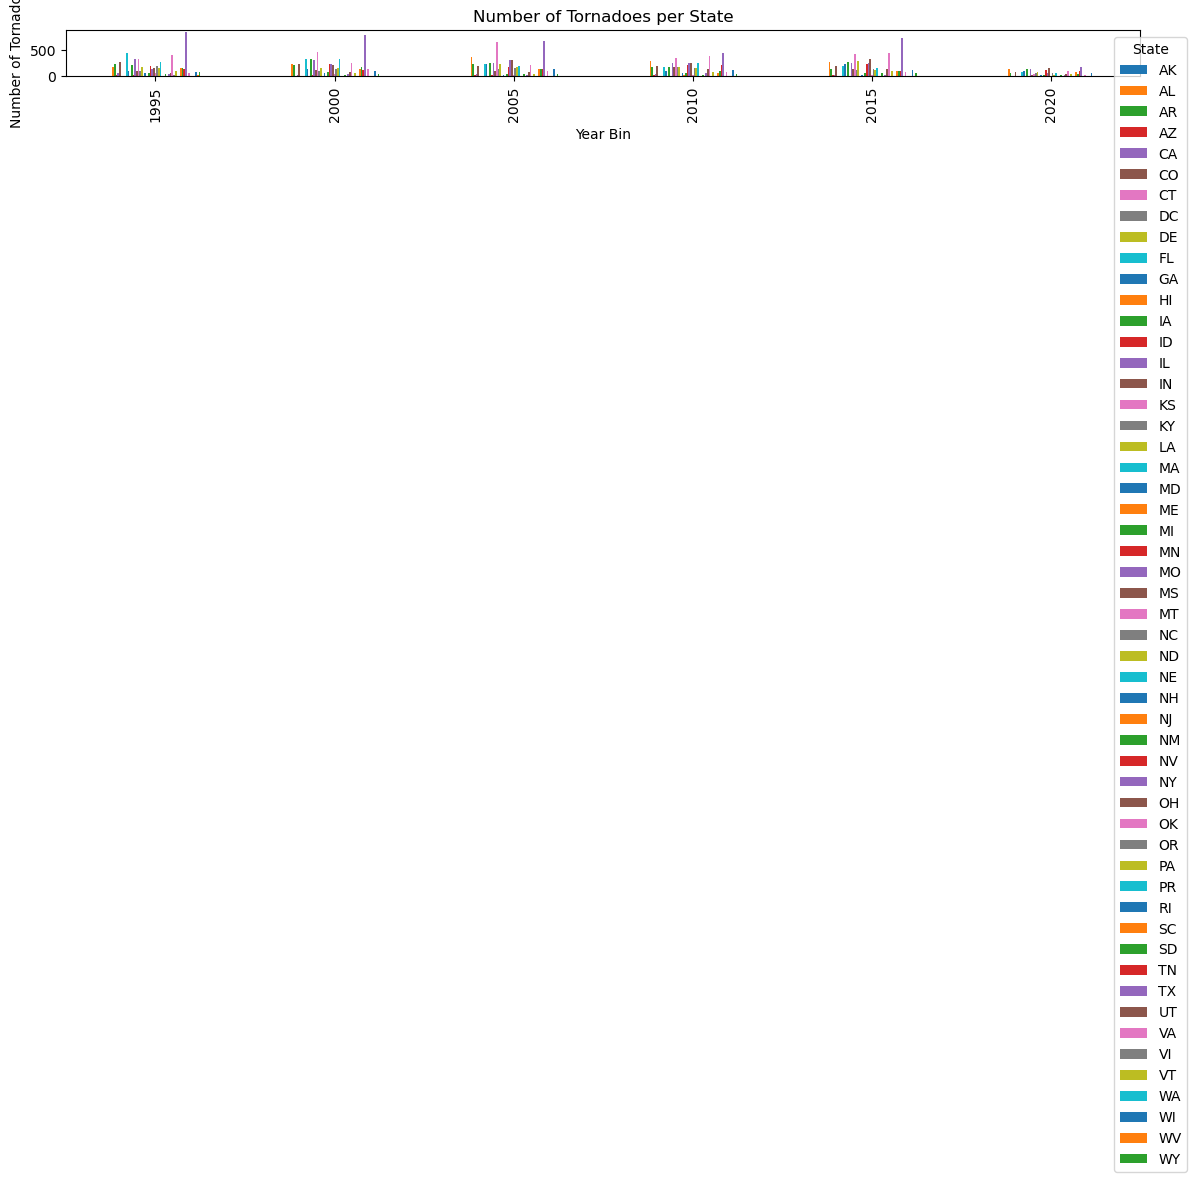

In [62]:
#create a new column that bins years in groups of 5
df['year_bin'] = (df['yr'] // 5) * 5

#group by state and the binned year, then the count
counts = df.groupby(['st', 'year_bin']).size().unstack(fill_value=0)

#plot
counts.T.plot(kind='bar', stacked=False, figsize=(12,7))
plt.title("Number of Tornadoes per State")
plt.xlabel("Year Bin")
plt.ylabel("Number of Tornadoes")
plt.legend(title="State", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

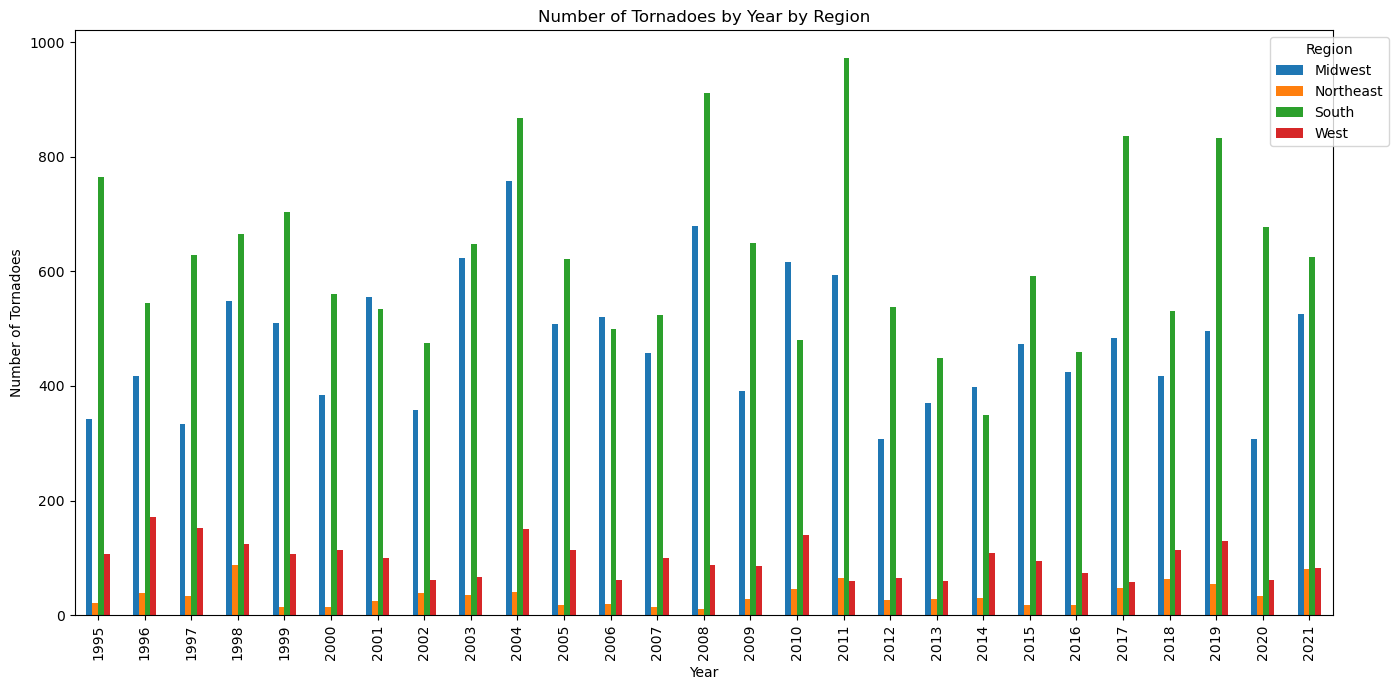

In [70]:
#count tornadoes by year and by region
tornado_counts = df.groupby(['yr', 'region']).size().unstack(fill_value=0)

#plot
tornado_counts.plot(kind="bar", stacked=False, figsize=(14,7))
plt.title("Number of Tornadoes by Year by Region")
plt.xlabel("Year")
plt.ylabel("Number of Tornadoes")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Start of Milestone 2

In [18]:
#Drop any features that are not useful for your model building and explain why they are not useful.

#remove slat, slon, elat, elon
cols_to_remove = ['slat', 'slon', 'elat', 'elon']
df = df.drop(columns=[col for col in cols_to_remove if col in df.columns])

print(df.head())

     yr  mo  dy      date  st  mag  inj  fat   len  wid
0  1995   1   6  1/6/1995  LA    0    0    0   0.2   20
1  1995   1   6  1/6/1995  LA    1    0    0  15.0   20
2  1995   1   6  1/6/1995  LA    1    8    0   5.0   30
3  1995   1   6  1/6/1995  NC    0    3    1   2.0  150
4  1995   1   6  1/6/1995  NC    1    1    0   1.0   73


The reason I removed the starting latitude/longatude and ending latitude/longitude, is because I am not focusing on latitude/longitude. I could use those to look into where the what state the tornado ended in, since the starting state is listed in the dataset already. Leveraging an API to process the latitude/longitudes and creating a new column for ending state, is an option, but it is not what I am specifically looking into. What I am looking into is if the overall number of injuries/fatalities has decreased over time with tornados. 

In [21]:
#find how many 0s are in the width column, since a tornado cannot have a width of 0 
if 'wid' in df.columns:
    zero_count = (df['wid'] == 0).sum()
    print("0s in 'wid' column:", zero_count)
else:
    print("wid column not found in the DataFrame.")

0s in 'wid' column: 473


In [23]:
#find the mode of width
if 'wid' in df.columns:
    mode_values = df['wid'].mode()
    print("Mode of 'wid' column:", list(mode_values))
else:
    print("'wid' column not found in the DataFrame.")

Mode of 'wid' column: [50]


In [25]:
#replace the 0s in wid with the mode
if 'wid' in df.columns:
    mode_value = df['wid'].mode()[0]
    df['wid'] = df['wid'].replace(0, mode_value)

print(df.head())

     yr  mo  dy      date  st  mag  inj  fat   len  wid
0  1995   1   6  1/6/1995  LA    0    0    0   0.2   20
1  1995   1   6  1/6/1995  LA    1    0    0  15.0   20
2  1995   1   6  1/6/1995  LA    1    8    0   5.0   30
3  1995   1   6  1/6/1995  NC    0    3    1   2.0  150
4  1995   1   6  1/6/1995  NC    1    1    0   1.0   73


In [27]:
#turning length and width into total area of tornado
#this will allow me to look at total area instead of piecing width and length together to find the same thing
#will the area of impact have a relationship to higher fatalities, has this changed throughout the years?

df['area'] = df['wid'] * df['len']

print (df['area'])

0           4.0
1         300.0
2         150.0
3         300.0
4          73.0
          ...  
33359     328.5
33360    3513.0
33361      47.5
33362     412.5
33363     187.5
Name: area, Length: 33364, dtype: float64


In [29]:
#by engineering a storm severity column, it can look at how many states had what level of storm, and has the severity changed over time. 
def categorize_severity(row):
    if row['fat'] > 5 or row['inj'] > 20:
        return 'Severe'
    elif row['fat'] > 0 or row['inj'] > 0:
        return 'Moderate'
    else:
        return 'Mild'

df['storm_severity'] = df.apply(categorize_severity, axis=1)

print(df['storm_severity'])

0            Mild
1            Mild
2        Moderate
3        Moderate
4        Moderate
           ...   
33359        Mild
33360        Mild
33361        Mild
33362        Mild
33363    Moderate
Name: storm_severity, Length: 33364, dtype: object


In [31]:
#knowing what season the storms happened in, can help determine if the season the storms happened has shifted over time. 
#has tornado season shifted in the global climate change?

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

print(df['season'])

0        Winter
1        Winter
2        Winter
3        Winter
4        Winter
          ...  
33359    Winter
33360    Winter
33361    Winter
33362    Winter
33363    Winter
Name: season, Length: 33364, dtype: object


In [66]:
#grouping the 50 states into regions (followed the Census data), to allow for easier encoding for modeling
state_to_region = {
    #Northeast
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast',
    'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    #Midwest
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    #South
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South',
    'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South',
    'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    #West
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'UT': 'West', 'WY': 'West',
    'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

In [68]:
df['region'] = df['st'].map(state_to_region)

Milestone 3

I chose logistic regression because it helps understand how the factors influence storm severity. Another reason is because my target is categorical, and that is what logistic regression is designed for. Looking at both season and severity, it is the logical choice since they are both categorical columns. Logistic regression was efficient for my severity, and proved to fit well. 

As logistic regression worked well for storm severity, it did not work well for season. I kept season in here as a reminder to change it before completing the final. I will find another model to use which can handle the inbalance better, as most storms happen in spring. I will try random forest for my model, and find one that is better fit. I know I only needed to do one model, but I wanted to get a jump, and do multiple. 

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

#encode storm severity to numeric
severity_map = {'Mild': 0, 'Moderate': 1, 'Severe': 2}
df['severity_num'] = df['storm_severity'].map(severity_map)

In [39]:
#encode season
season_map = {season: idx for idx, season in enumerate(df['season'].unique())}
df['season_num'] = df['season'].map(season_map)

In [41]:
#label features and targets
features = ['wid', 'len', 'area']
X = df[features]
y = df[['severity_num', 'season_num']]

In [43]:
#scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [45]:
#train and split to  80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [47]:
#multioutput classifier using logistic regression
base_model = LogisticRegression(max_iter=2000)
multi_clf = MultiOutputClassifier(base_model)
multi_clf.fit(X_train, y_train)

MultiOutputClassifier(estimator=LogisticRegression(max_iter=2000))

In [49]:
#predict
y_pred = multi_clf.predict(X_test)


In [51]:
#evaluation
print("Storm Severity")
print("Accuracy:", accuracy_score(y_test['severity_num'], y_pred[:,0]))
print("Classification Report:\n", classification_report(y_test['severity_num'], y_pred[:,0], target_names=severity_map.keys()))


Storm Severity
Accuracy: 0.9246216094710026
Classification Report:
               precision    recall  f1-score   support

        Mild       0.93      1.00      0.96      6158
    Moderate       0.45      0.07      0.13       465
      Severe       1.00      0.14      0.25        50

    accuracy                           0.92      6673
   macro avg       0.79      0.40      0.44      6673
weighted avg       0.90      0.92      0.90      6673



The accuracy looks good, but since the classes are inbalanced, my model is good at finding mild, but struggles with moderate and severe. I will continue to find other models to better represent all the severity types

In [54]:
print("\nSeason")
reverse_season_map = {v: k for k, v in season_map.items()}
season_names = [reverse_season_map[i] for i in sorted(reverse_season_map.keys())]
print("Accuracy:", accuracy_score(y_test['season_num'], y_pred[:,1]))
print(classification_report(y_test['season_num'], y_pred[:,1], target_names=season_names, zero_division=0))


Season
Accuracy: 0.43818372546081225
              precision    recall  f1-score   support

      Winter       0.00      0.00      0.00       654
      Spring       0.44      1.00      0.61      2926
      Summer       0.00      0.00      0.00      2099
        Fall       0.00      0.00      0.00       994

    accuracy                           0.44      6673
   macro avg       0.11      0.25      0.15      6673
weighted avg       0.19      0.44      0.27      6673



Spring is the most prevelant season for storms, so it will predict spring almost every time. 

Changes to Milestone 3

In [191]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils import resample

#encode severity and region
le_region = LabelEncoder()
df['region'] = df['region'].astype(str)
df['region_encoded'] = le_region.fit_transform(df['region'])
le_severity = LabelEncoder()
df['storm_severity'] = df['storm_severity'].astype(str)
df['storm_severity_encoded'] = le_severity.fit_transform(df['storm_severity'])



In [193]:
df['wid'] = pd.to_numeric(df['wid'], errors='coerce').fillna(0).astype(int)
df['len'] = pd.to_numeric(df['len'], errors='coerce').fillna(0).astype(int)
df['area'] = df['area'].astype(int)

In [195]:
#prep data
features = ['wid', 'len', 'area']
X = df[features]
y = df[['storm_severity_encoded', 'region_encoded']]

In [197]:
#split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['storm_severity_encoded']
)

In [199]:
#upsample the minority
train = X_train.copy()
train['storm_severity_encoded'] = y_train['storm_severity_encoded'].values
train['region_encoded'] = y_train['region_encoded'].values


In [201]:
#separate
mild = train[train['storm_severity_encoded'] == le_severity.transform(['Mild'])[0]]
moderate = train[train['storm_severity_encoded'] == le_severity.transform(['Moderate'])[0]]
severe = train[train['storm_severity_encoded'] == le_severity.transform(['Severe'])[0]]


In [203]:
#upsample to max class
mild_upsampled = resample(mild, replace=True, n_samples=max_size, random_state=42)
moderate_upsampled = resample(moderate, replace=True, n_samples=max_size, random_state=42)
severe_upsampled = resample(severe, replace=True, n_samples=max_size, random_state=42)


In [205]:
#combine
train_upsampled = pd.concat([mild_upsampled, moderate_upsampled, severe_upsampled])


In [207]:
#shuffle
train_upsampled = train_upsampled.sample(frac=1, random_state=42).reset_index(drop=True)


In [209]:
#prepare
X_train_up = train_upsampled[features]
y_train_up = train_upsampled[['storm_severity_encoded', 'region_encoded']]


In [211]:
#model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
multi = MultiOutputClassifier(rf)
multi.fit(X_train_up, y_train_up)


MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [212]:
#predict
y_pred = multi.predict(X_test)

In [213]:

print("Classification report for Storm Severity:")
print(classification_report(
    y_test['storm_severity_encoded'], 
    y_pred[:,0], 
    target_names=le_severity.classes_, 
    zero_division=0
))
print("Classification report for Region:")
print(classification_report(
    y_test['region_encoded'], 
    y_pred[:,1], 
    target_names=le_region.classes_, 
    zero_division=0
))

Classification report for Storm Severity:
              precision    recall  f1-score   support

        Mild       0.94      0.82      0.88      6161
    Moderate       0.13      0.34      0.19       458
      Severe       0.07      0.20      0.10        50

    accuracy                           0.78      6669
   macro avg       0.38      0.45      0.39      6669
weighted avg       0.88      0.78      0.82      6669

Classification report for Region:
              precision    recall  f1-score   support

     Midwest       0.40      0.29      0.34      2492
   Northeast       0.02      0.01      0.01       209
       South       0.53      0.68      0.60      3426
        West       0.29      0.21      0.25       542

    accuracy                           0.48      6669
   macro avg       0.31      0.30      0.30      6669
weighted avg       0.45      0.48      0.45      6669



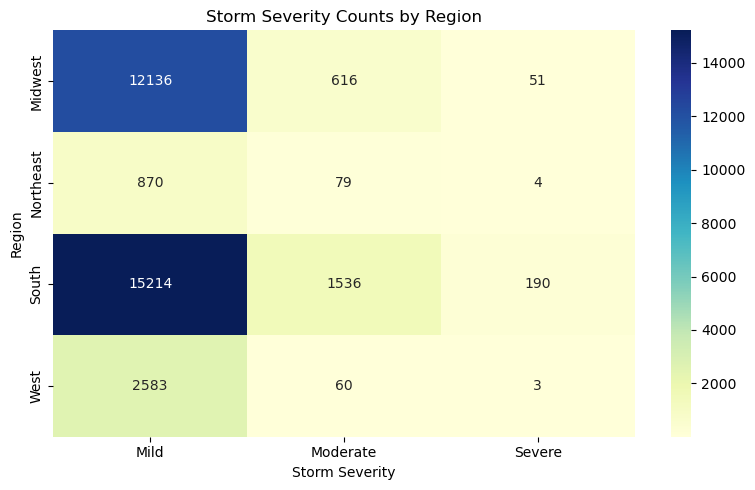

In [219]:
import seaborn as sns
#create a crosstab
severity_region_ct = pd.crosstab(df['region'], df['storm_severity'])

#plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(severity_region_ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Storm Severity Counts by Region")
plt.ylabel("Region")
plt.xlabel("Storm Severity")
plt.tight_layout()
plt.show()